# 01. Exploratory Data Analysis (EDA) - German Credit Risk Dataset
**Author**: Yordanos Andargachew (Phone: `+251 952 190 305`)  
**Project**: Bank Loan Risk Prediction System  

---

## 1. Introduction & Problem Context
Credit risk scoring is a foundational machine learning task in commercial and retail banking. The primary goal is assessing whether a loan applicant presents a **Good Risk** (high likelihood of timely repayment) or a **Bad Risk** (high propensity for credit default or delinquency).

In this notebook, we perform an in-depth exploratory data analysis on the German Credit Risk dataset (1,000 credit records).

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load dataset
data_path = os.path.join("..", "data", "dataset.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "dataset.csv")

df = pd.read_csv(data_path)
print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head(10)

Dataset Loaded Successfully! Shape: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
5,35,male,1,free,NaN,NaN,9055,36,education,good
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,35,male,3,rent,little,moderate,6948,36,car,good
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,28,male,3,own,little,moderate,5234,30,car,bad


## 2. Dataset Schema & Missing Value Audit
Let's inspect data types, memory footprint, and missingness across all features.

In [2]:
print("=== Dataset Information ===")
df.info()

print("\n=== Missing Values Summary ===")
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
missing_summary

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB

=== Missing Values Summary ===


,Missing Count,Missing Percentage (%)
Age,0,0.0
Sex,0,0.0
Job,0,0.0
Housing,0,0.0
Saving accounts,183,18.3
Checking account,394,39.4
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0
Risk,0,0.0


/tmp/ipykernel_46698/1689270019.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_summary.index, y=missing_summary['Missing Percentage (%)'], palette="viridis")


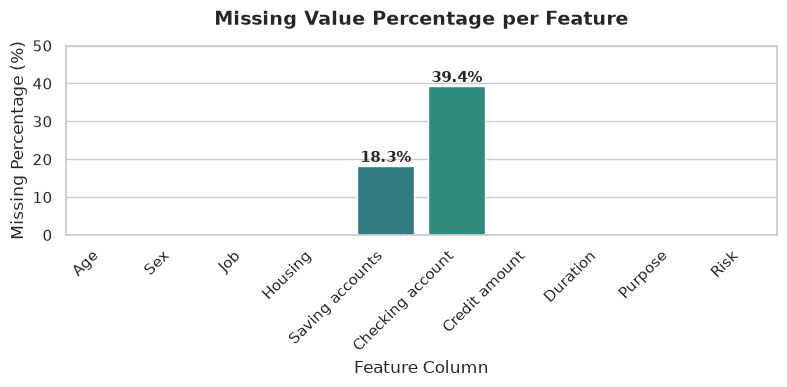

In [3]:
# Visualize Missing Values
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_summary.index, y=missing_summary['Missing Percentage (%)'], palette="viridis")
plt.title("Missing Value Percentage per Feature", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Feature Column")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 50)
for i, v in enumerate(missing_summary['Missing Percentage (%)']):
    if v > 0:
        plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Target Distribution: Good vs Bad Risk Imbalance
A crucial aspect of credit risk modeling is class imbalance. Let's examine the target class `Risk`.

Risk Class Counts:
Risk
good    700
bad     300
Name: count, dtype: int64

Default Rate (Bad Risk): 30.0%


/tmp/ipykernel_46698/281033328.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], data=df, x='Risk', palette=['#10b981', '#ef4444'])


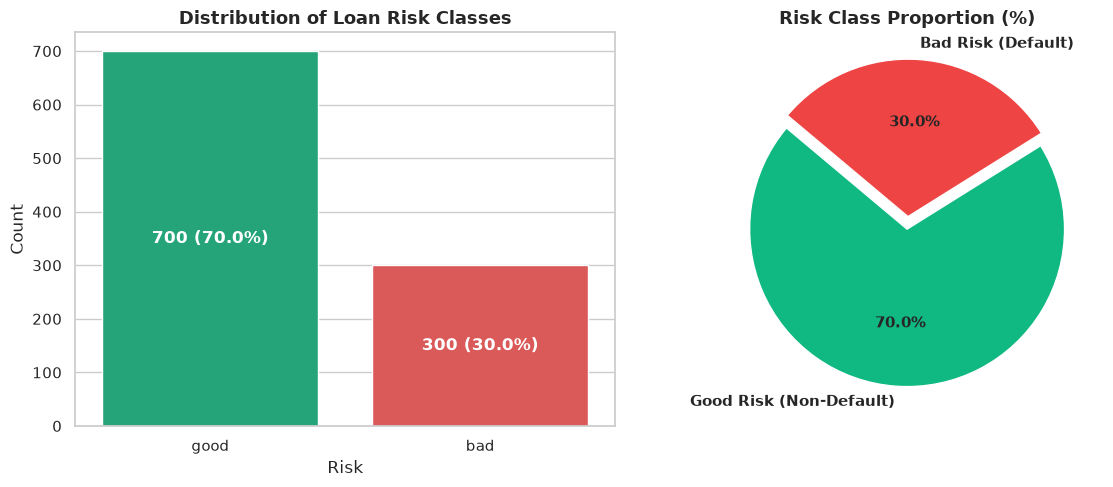

In [4]:
risk_counts = df['Risk'].value_counts()
print("Risk Class Counts:")
print(risk_counts)
print(f"\nDefault Rate (Bad Risk): {(risk_counts['bad'] / len(df)) * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
sns.countplot(ax=axes[0], data=df, x='Risk', palette=['#10b981', '#ef4444'])
axes[0].set_title("Distribution of Loan Risk Classes", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())} ({p.get_height()/len(df):.1%})", 
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(risk_counts, labels=['Good Risk (Non-Default)', 'Bad Risk (Default)'], 
           autopct='%1.1f%%', colors=['#10b981', '#ef4444'], explode=[0, 0.08],
           startangle=140, textprops={'fontweight': 'bold'})
axes[1].set_title("Risk Class Proportion (%)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Numerical Feature Distributions by Risk Category
Analyzing `Age`, `Credit amount`, and `Duration` partitioned by Risk classification.

/tmp/ipykernel_46698/376459730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df, x='Risk', y=col, palette=['#10b981', '#ef4444'])
/tmp/ipykernel_46698/376459730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df, x='Risk', y=col, palette=['#10b981', '#ef4444'])
/tmp/ipykernel_46698/376459730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df, x='Risk', y=col, palette=['#10b981', '#ef4444'])


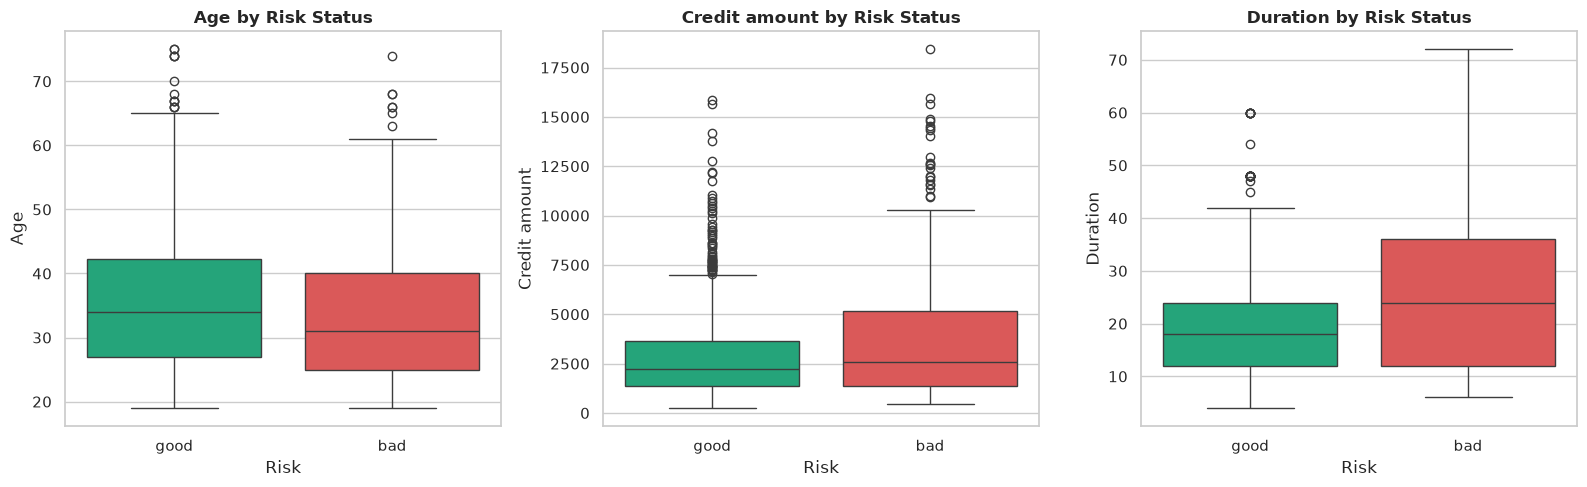

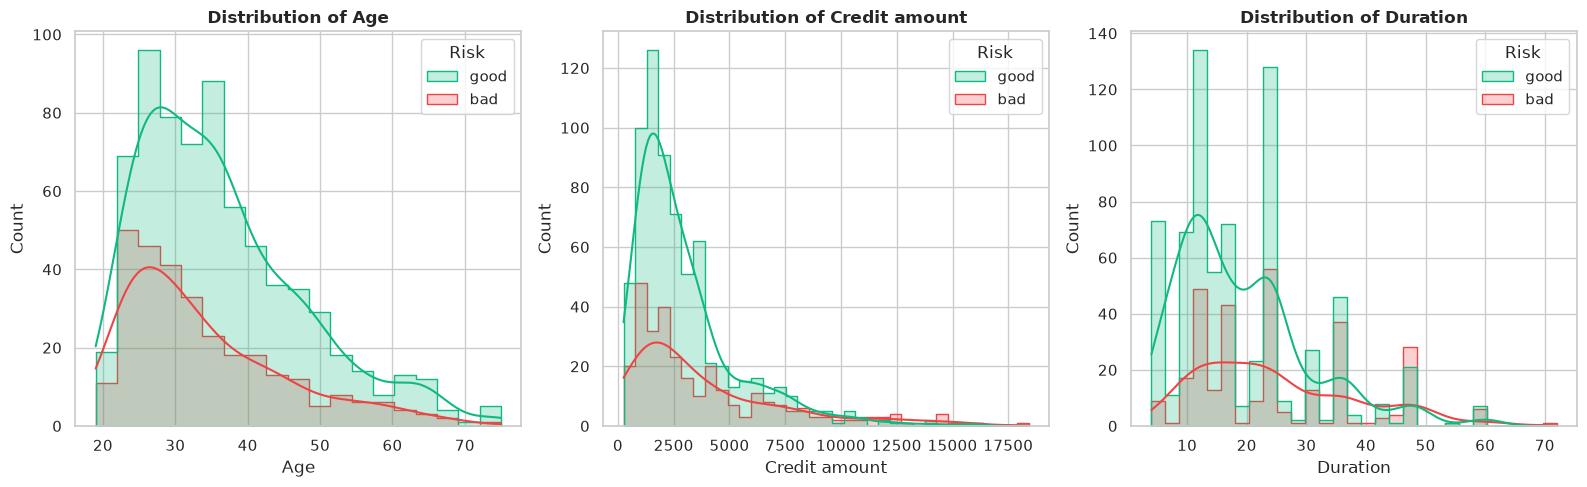

In [5]:
num_cols = ['Age', 'Credit amount', 'Duration']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(ax=axes[i], data=df, x='Risk', y=col, palette=['#10b981', '#ef4444'])
    axes[i].set_title(f"{col} by Risk Status", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_cols):
    sns.histplot(ax=axes[i], data=df, x=col, hue='Risk', kde=True, element="step", palette=['#10b981', '#ef4444'])
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Categorical Feature Distributions vs Risk
Examining `Housing`, `Purpose`, `Sex`, `Job`, `Saving accounts`, and `Checking account` against credit outcomes.

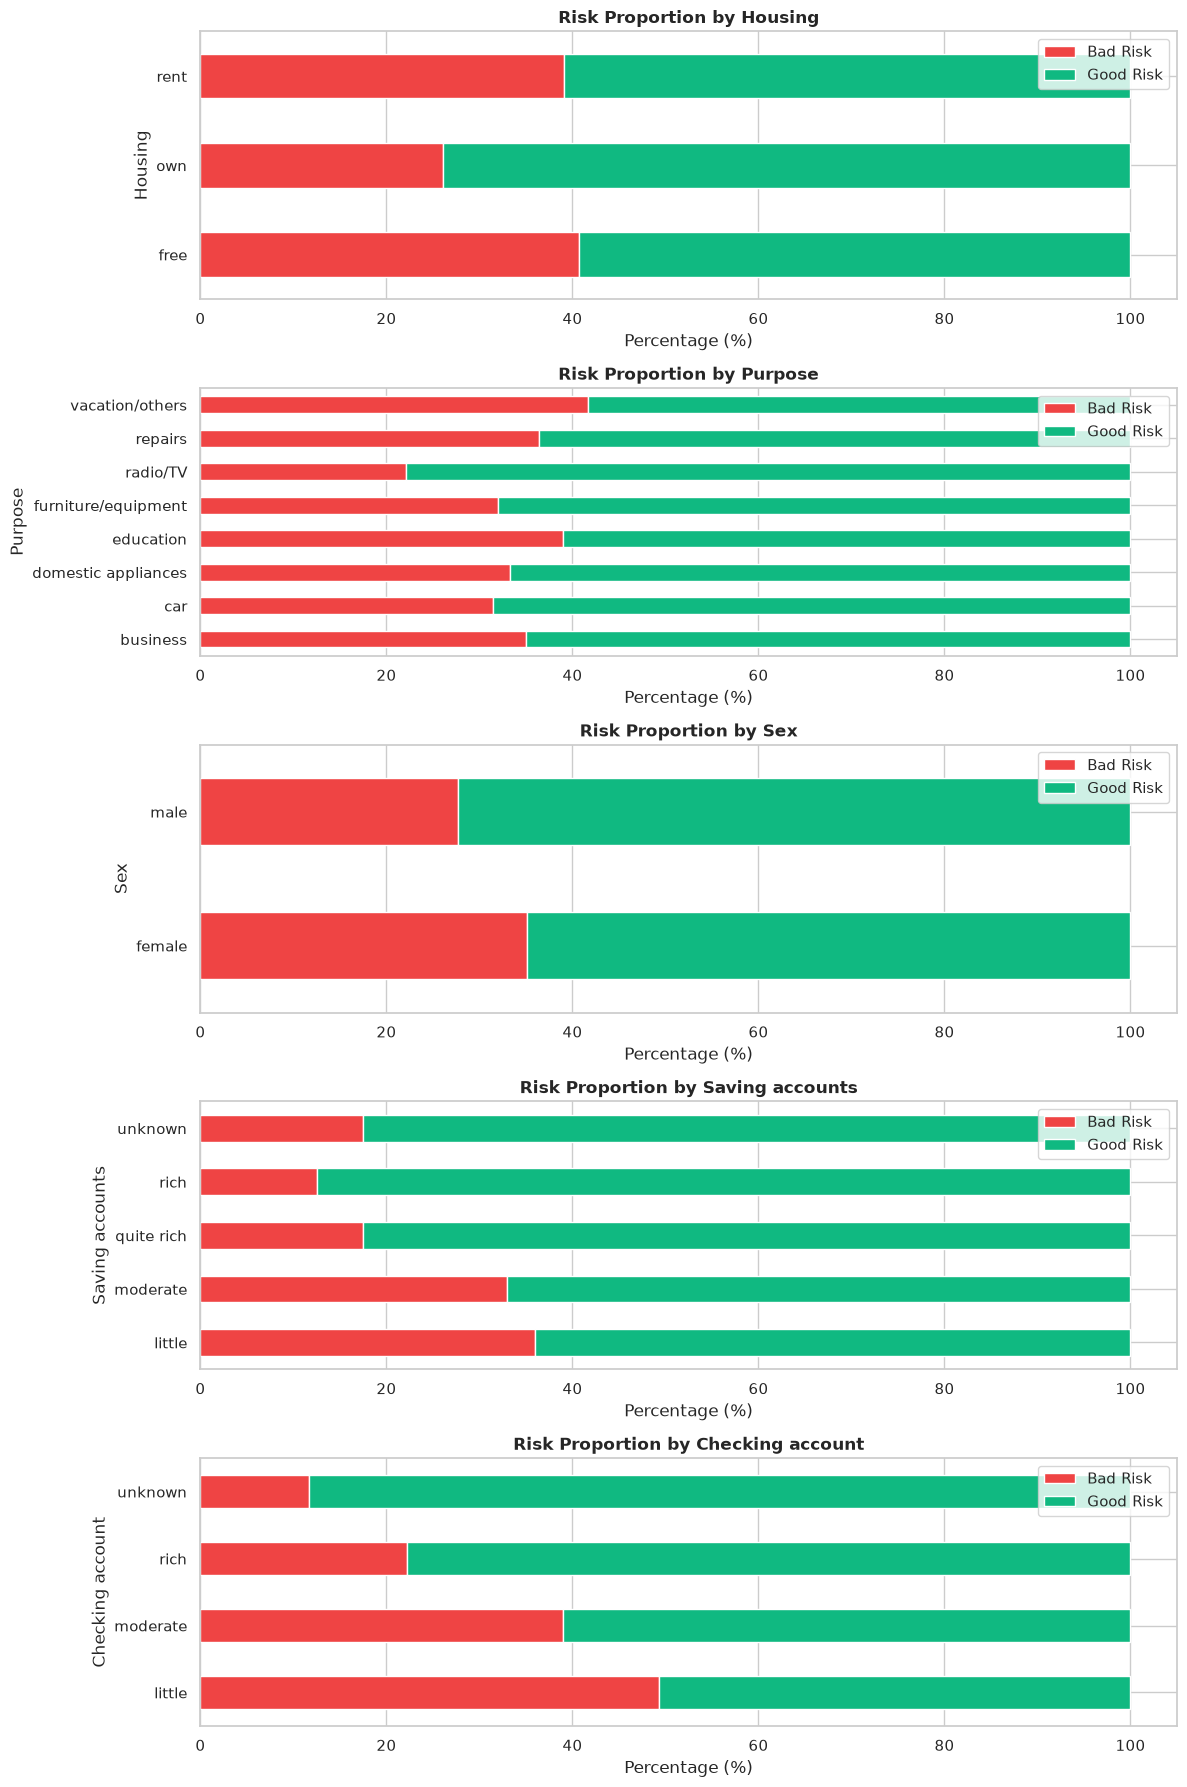

In [6]:
cat_cols = ['Housing', 'Purpose', 'Sex', 'Saving accounts', 'Checking account']

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 18))
for i, col in enumerate(cat_cols):
    cross_tab = pd.crosstab(df[col].fillna('unknown'), df['Risk'], normalize='index') * 100
    cross_tab.plot(kind='barh', stacked=True, ax=axes[i], color=['#ef4444', '#10b981'])
    axes[i].set_title(f"Risk Proportion by {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel(col)
    axes[i].legend(["Bad Risk", "Good Risk"], loc="upper right")
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap of Numerical Features

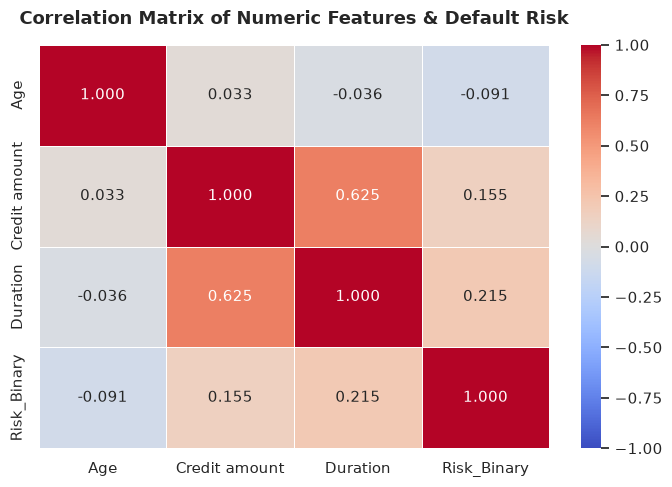

In [7]:
# Add binary risk column for correlation (1 for bad, 0 for good)
corr_df = df[num_cols].copy()
corr_df['Risk_Binary'] = (df['Risk'] == 'bad').astype(int)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features & Default Risk", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 7. Key Findings & EDA Summary
1. **Target Imbalance**: 70% Good Risk vs 30% Bad Risk. Models must use class weighting or balanced loss objectives.
2. **Account Status is Crucial**: Applicants with 'little' or low checking accounts show default rates exceeding 45%, whereas those with 'rich' accounts have very low default rates (<15%).
3. **Loan Duration & Amount**: Longer duration loans (>36 months) and larger credit amounts correlate with increased default risk.
4. **Missing Values**: Missing values in `Saving accounts` (18.3%) and `Checking account` (39.4%) signify individuals with no existing accounts at this institution and must be retained as an informative category (`unknown`).